In [1]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print(df[df['TotalCharges'] == ' '].shape[0])

11


In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)   # step 1: expose the blanks
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # step 2: convert to float
df['TotalCharges'] = df['TotalCharges'].fillna(0).astype(float)  # step 3: fill the 11 NaNs with 0

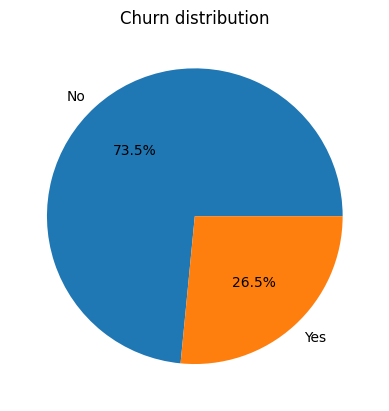

In [ ]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Churn distribution')
plt.ylabel('')
plt.show()

In [ ]:
df.shape

(7043, 21)

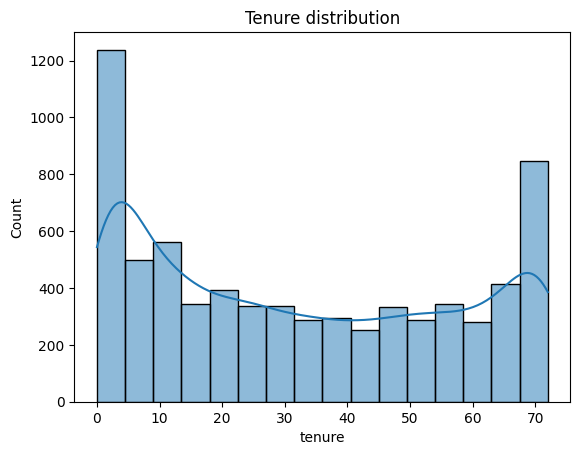

In [ ]:
sns.histplot(df['tenure'], kde=True)
plt.title('Tenure distribution')
plt.show()




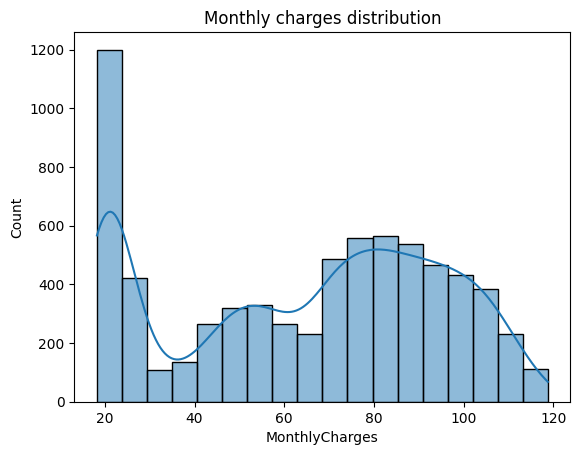

In [ ]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly charges distribution')
plt.show()




Text(0.5, 0, 'Churn')

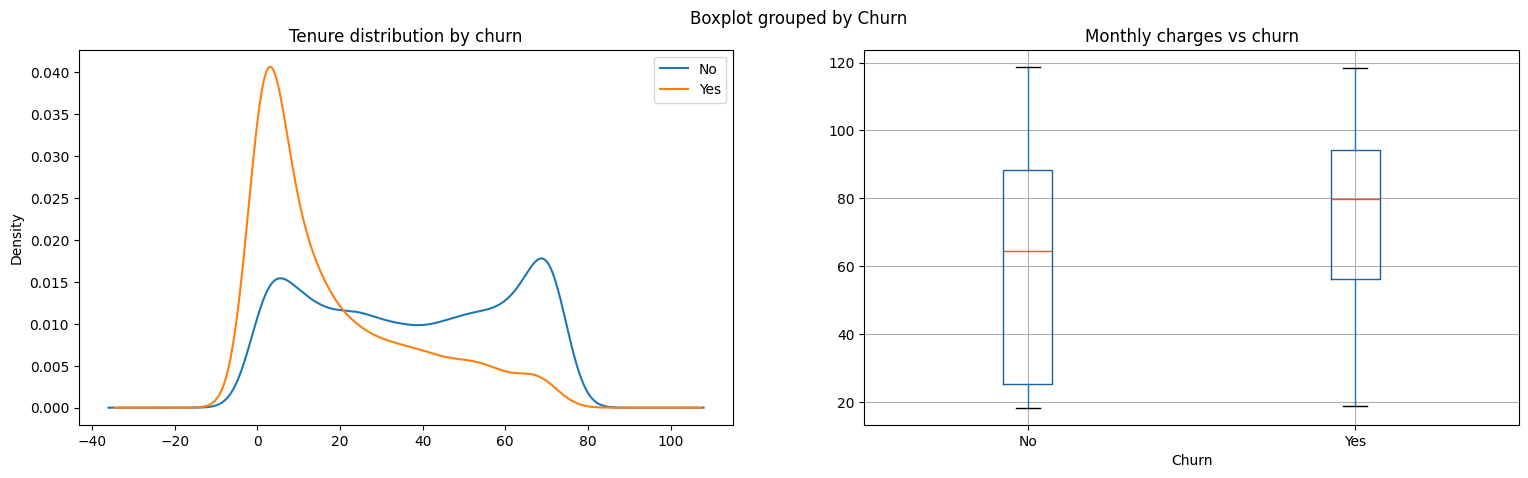

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Tenure KDE by churn
for label, grp in df.groupby('Churn'):
    grp['tenure'].plot.kde(ax=axes[0], label=label)
axes[0].set_title('Tenure distribution by churn')
axes[0].legend()

# Plot 2: Monthly charges boxplot
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1],
           boxprops=dict(color='#185FA5'), medianprops=dict(color='#D85A30'))
axes[1].set_title('Monthly charges vs churn')
axes[1].set_xlabel('Churn')

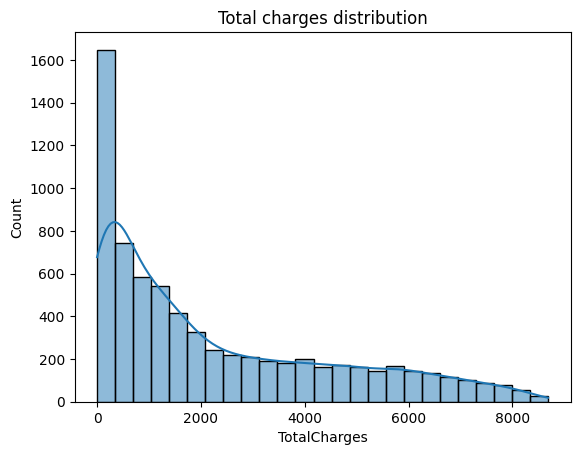

Text(0, 0.5, 'Average total charges')

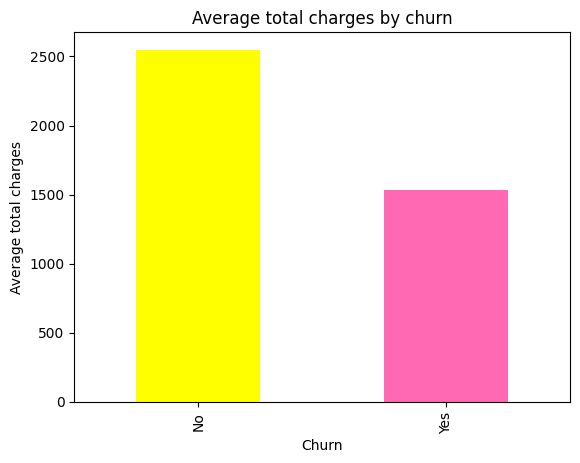

In [ ]:
sns.histplot(df['TotalCharges'], kde=True)
plt.title('Total charges distribution')
plt.show()

df.groupby('Churn')['TotalCharges'].mean().plot(kind='bar', color=['yellow', 'hotpink'])
plt.title('Average total charges by churn')
plt.xlabel('Churn')
plt.ylabel('Average total charges')

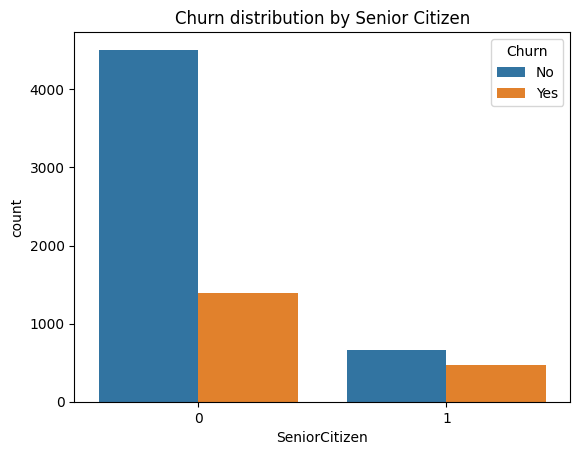

In [ ]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title('Churn distribution by Senior Citizen')
plt.show()

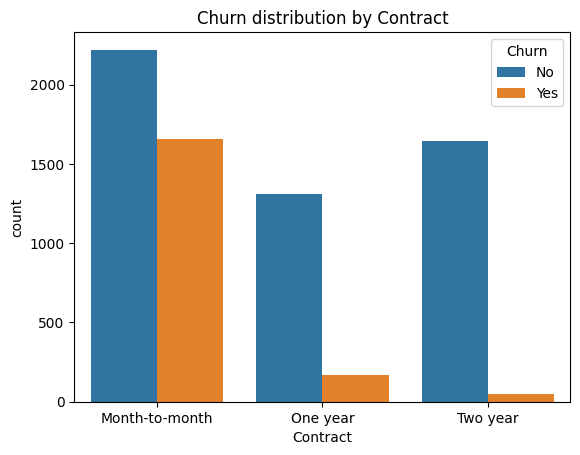

In [ ]:
sns.countplot(data = df, x='Contract', hue='Churn')
plt.title('Churn distribution by Contract')
plt.show()

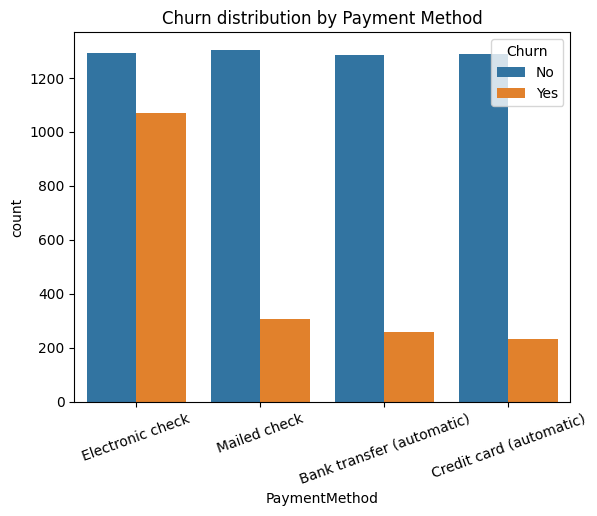

In [ ]:
sns.countplot(data = df, x='PaymentMethod', hue='Churn')
plt.title('Churn distribution by Payment Method')
plt.xticks(rotation=20)
plt.show()

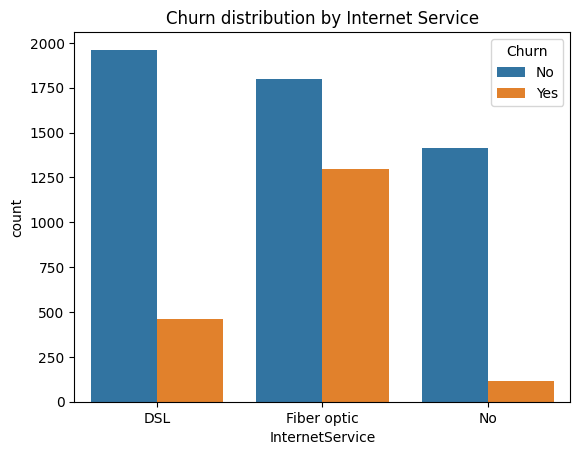

In [ ]:
sns.countplot(data = df, x='InternetService', hue='Churn')
plt.title('Churn distribution by Internet Service')
plt.show()


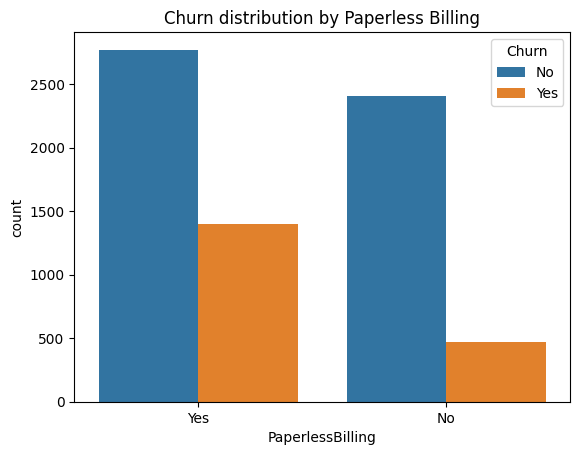

In [ ]:
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title('Churn distribution by Paperless Billing')
plt.show()

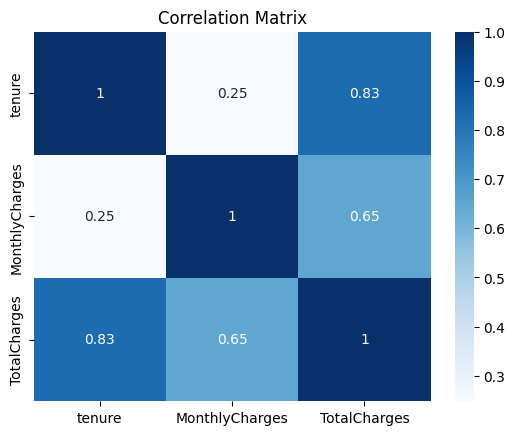

In [ ]:
num_cols=['tenure', 'MonthlyCharges', 'TotalCharges']
sns.heatmap(df[num_cols].corr(), annot= True, cmap= 'Blues')
plt.title('Correlation Matrix')
plt.show()


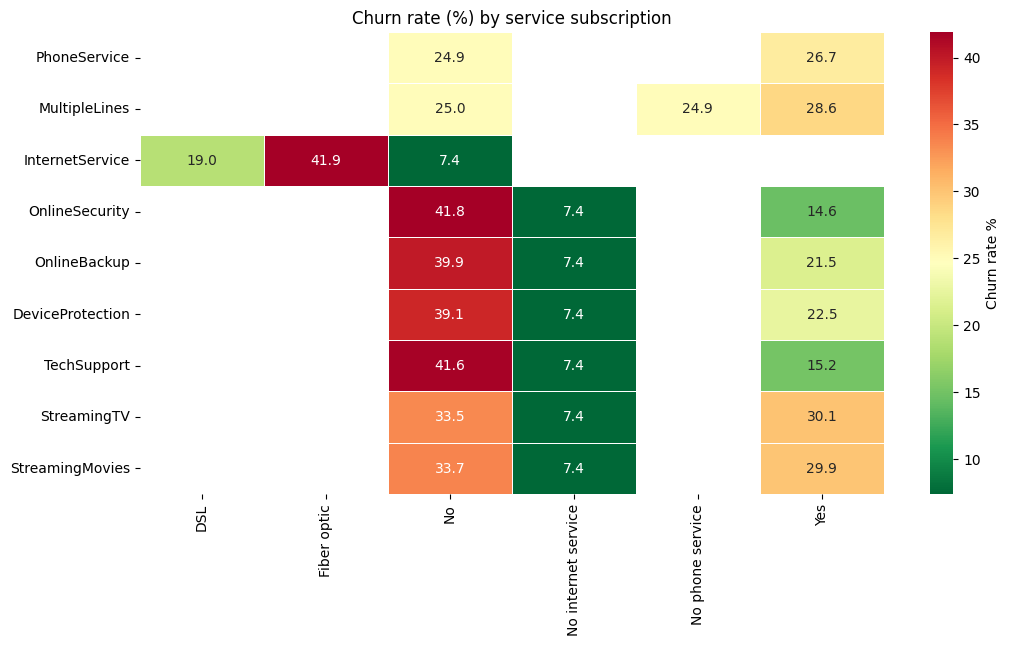

In [ ]:
service_cols = ['PhoneService','MultipleLines','InternetService',
                'OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

churn_rates = {}
for col in service_cols:
    churn_rates[col] = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )

churn_df = pd.DataFrame(churn_rates).T
plt.figure(figsize=(12, 6))
sns.heatmap(churn_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn rate %'})
plt.title('Churn rate (%) by service subscription')
plt.show()

/tmp/ipykernel_756/844933455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_tenure, x='Tenure group', y='Churn rate %',


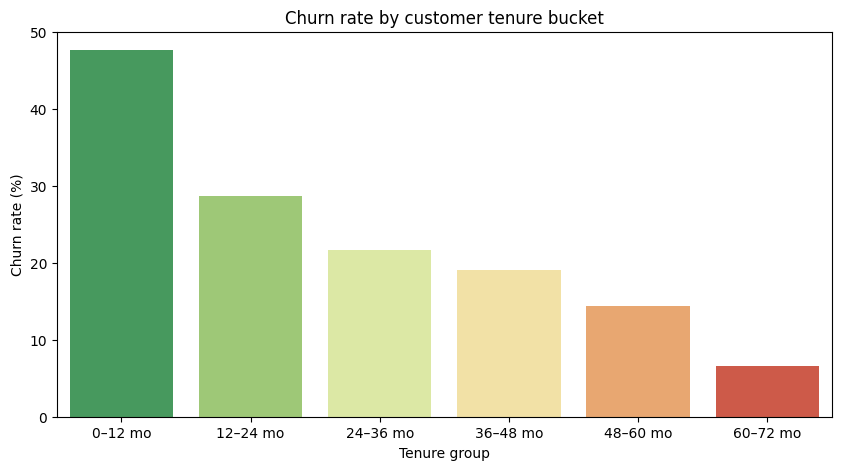

In [ ]:
# Create tenure buckets
df_temp = df.copy()
df_temp['Tenure_group'] = pd.cut(df_temp['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0–12 mo', '12–24 mo', '24–36 mo', '36–48 mo', '48–60 mo', '60–72 mo'])

churn_by_tenure = df_temp.groupby('Tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_by_tenure.columns = ['Tenure group', 'Churn rate %']

plt.figure(figsize=(10, 5))
sns.barplot(data=churn_by_tenure, x='Tenure group', y='Churn rate %',
            palette='RdYlGn_r')
plt.title('Churn rate by customer tenure bucket')
plt.ylabel('Churn rate (%)')
plt.show()

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group', 'Tenure_group'],
      dtype='object')

In [ ]:
df.shape

(7043, 23)

In [ ]:
df.drop(columns=['tenure_group', 'Tenure_group'], inplace=True)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.shape

(7043, 21)

In [7]:
cols_fix = ['MultipleLines','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies']
for cols in cols_fix:
  df[cols] = df[cols].replace({
      'No phone service': 'No',
      'No internet service': 'No'
  })


In [8]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling', 'Churn']
binary_map = {'Yes':1, 'No': 0, 'Female': 1, 'Male':0}
for cols in binary_cols:
  df[cols] = df[cols].map(binary_map)

In [9]:
#InternetService: DSL, Fiber optic, No
#Contract:  Month-to-Month, One year, two years
#PaymentMethod: Electric check, Mailed checl, Bank transfer(automatic), Credit card(automatic)

df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})


In [10]:
df.dtypes

,0
customerID,object
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_unscaled = df.copy()
df[num_cols]= scaler.fit_transform(df[num_cols])

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,1,0,-1.277445,0,0,0,1,...,-1.160323,-0.992611,0,0,0,0,0,0,1,0
1,5575-GNVDE,0,0,0,0,0.066327,1,0,1,0,...,-0.259629,-0.172165,0,0,0,1,0,0,0,1
2,3668-QPYBK,0,0,0,0,-1.236724,1,0,1,1,...,-0.362660,-0.958066,1,0,0,0,0,0,0,1
3,7795-CFOCW,0,0,0,0,0.514251,0,0,1,0,...,-0.746535,-0.193672,0,0,0,1,0,0,0,0
4,9237-HQITU,1,0,0,0,-1.236724,1,0,0,0,...,0.197365,-0.938874,1,1,0,0,0,0,1,0


In [13]:
df.drop(columns=['customerID', 'TotalCharges'], inplace=True)

In [14]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y ensures both splits have same 73/27 churn ratio

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_res.value_counts().to_dict())
# Before: {0: 4121, 1: 1521}
# After:  {0: 4121, 1: 4121}  ← perfectly balanced

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [15]:
# Confirm no nulls remain
print(df.isnull().sum().sum())

# Confirm all columns are numeric
print(df.dtypes.unique())

# Confirm shape is sensible
print(f"Features: {X.shape[1]}, Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

0
[dtype('int64') dtype('float64')]
Features: 22, Train: 5634, Test: 1409


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'Churn',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [16]:
cluster_features = ['SeniorCitizen', 'tenure', 'OnlineSecurity', 'TechSupport','PaperlessBilling',
                    'MonthlyCharges','InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year',
                    'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']
X_cluster =df[cluster_features]

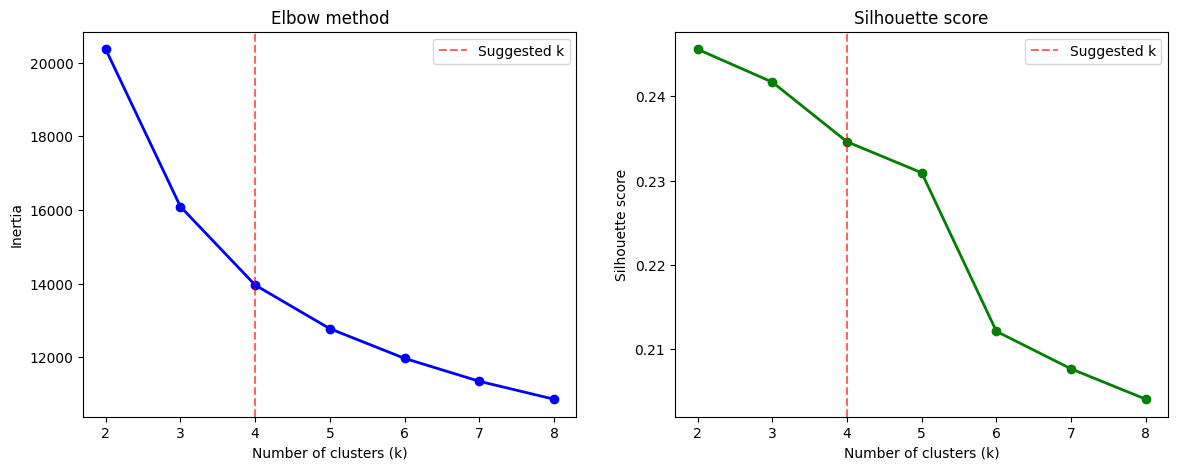

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K, inertia, 'bo-', linewidth=2, markersize=6)
axes[0].set_title('Elbow method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Suggested k')
axes[0].legend()

# Silhouette plot
axes[1].plot(K, silhouette, 'go-', linewidth=2, markersize=6)
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Suggested k')
axes[1].legend()

plt.show()

In [18]:
from sklearn.cluster import KMeans

k = 4  # adjust based on your elbow/silhouette plots
km = KMeans(n_clusters=k, random_state=42, n_init=10)
km.fit(X_cluster)

# Add cluster labels to BOTH scaled and unscaled dataframes
df['Cluster'] = km.labels_
df_unscaled['Cluster'] = km.labels_

print(df['Cluster'].value_counts())

Cluster
2    2038
1    1957
3    1943
0    1105
Name: count, dtype: int64


In [19]:
# Use unscaled df for readable interpretation
profile = df_unscaled.groupby('Cluster').agg(
    num_customers   = ('tenure', 'count'),
    avg_tenure      = ('tenure', 'mean'),
    avg_monthly     = ('MonthlyCharges', 'mean'),
    churn_rate      = ('Churn', 'mean'),
    senior_pct      = ('SeniorCitizen', 'mean'),
    fiber_pct       = ('InternetService_Fiber optic', 'mean'),
    security_pct    = ('OnlineSecurity', 'mean'),
    contract_1yr    = ('Contract_One year', 'mean'),
    contract_2yr    = ('Contract_Two year', 'mean'),
    payment_credit_pct=('PaymentMethod_Credit card (automatic)', 'mean'),
    payment_elec_pct=('PaymentMethod_Electronic check', 'mean'),
    payment_mail_pct=('PaymentMethod_Mailed check', 'mean')
).round(2)

print(profile)


         num_customers  avg_tenure  avg_monthly  churn_rate  senior_pct  \
Cluster                                                                   
0                 1105       54.21        32.93        0.05        0.07   
1                 1957       58.65        91.72        0.14        0.19   
2                 2038       11.72        37.11        0.23        0.07   
3                 1943       15.14        84.71        0.55        0.28   

         fiber_pct  security_pct  contract_1yr  contract_2yr  \
Cluster                                                        
0             0.00          0.20          0.26          0.61   
1             0.65          0.59          0.35          0.43   
2             0.00          0.18          0.20          0.08   
3             0.94          0.14          0.05          0.00   

         payment_credit_pct  payment_elec_pct  payment_mail_pct  
Cluster                                                          
0                      0.31     

In [20]:
cluster_names = {
    0: 'Long-term stable',
    1: 'High-value loyal',
    2: 'New customers',
    3: 'High-value at risk'
}
df['Cluster_Label'] = df['Cluster'].map(cluster_names)
df_unscaled['Cluster_Label'] = df_unscaled['Cluster'].map(cluster_names)

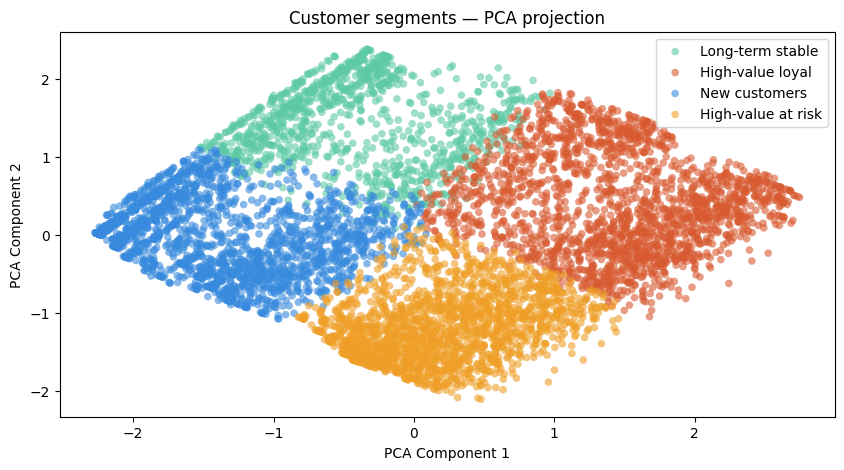

In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 5))
colors = ['#5DCAA5', '#D85A30', '#378ADD', '#EF9F27']
for i in range(k):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=cluster_names[i],
                alpha=0.6, s=30, edgecolors='none')

plt.title('Customer segments — PCA projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()

plt.show()

In [21]:
cluster_colors = {
    'Long-term stable':    '#5DCAA5',
    'High-value loyal':  '#D85A30',
    'New customers':      '#378ADD',
    'High-value at risk': '#EF9F27'
}
colors = [cluster_colors[cluster_names[i]] for i in range(4)]

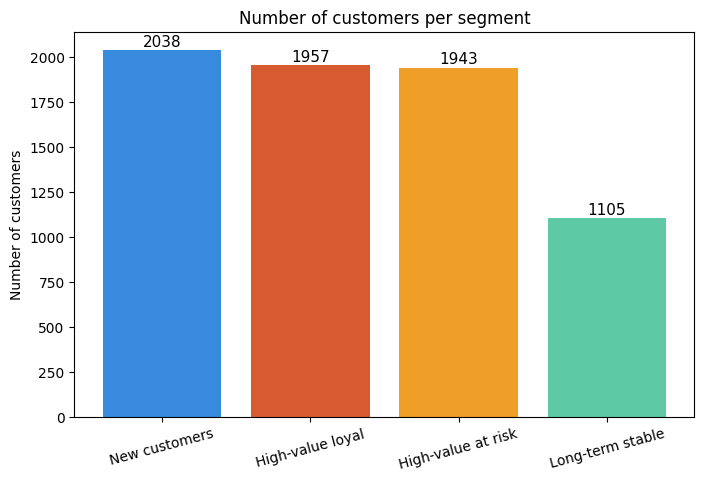

In [ ]:
#cluster size distribution
plt.figure(figsize=(8, 5))
counts = df_unscaled['Cluster_Label'].value_counts()
bars = plt.bar(counts.index, counts.values, color=[cluster_colors[c] for c in counts.index],
               edgecolor='none')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=11)
plt.title('Number of customers per segment')
plt.ylabel('Number of customers')
plt.xticks(rotation=15)

plt.show()

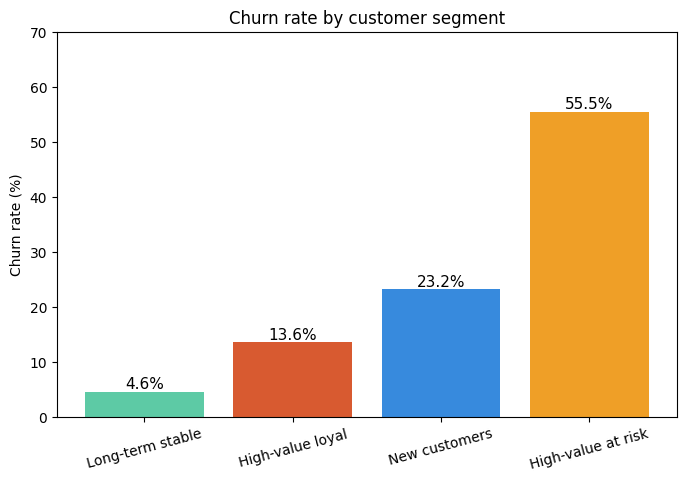

In [ ]:
#cluster rate per segment
churn_by_cluster = df_unscaled.groupby('Cluster_Label')['Churn'].mean() * 100
churn_by_cluster = churn_by_cluster.reindex(cluster_colors.keys())

plt.figure(figsize=(8, 5))
bars = plt.bar(churn_by_cluster.index, churn_by_cluster.values,
               color=[cluster_colors[c] for c in churn_by_cluster.index],
               edgecolor='none')
for bar, val in zip(bars, churn_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11)
plt.title('Churn rate by customer segment')
plt.ylabel('Churn rate (%)')
plt.ylim(0, 70)
plt.xticks(rotation=15)

plt.show()

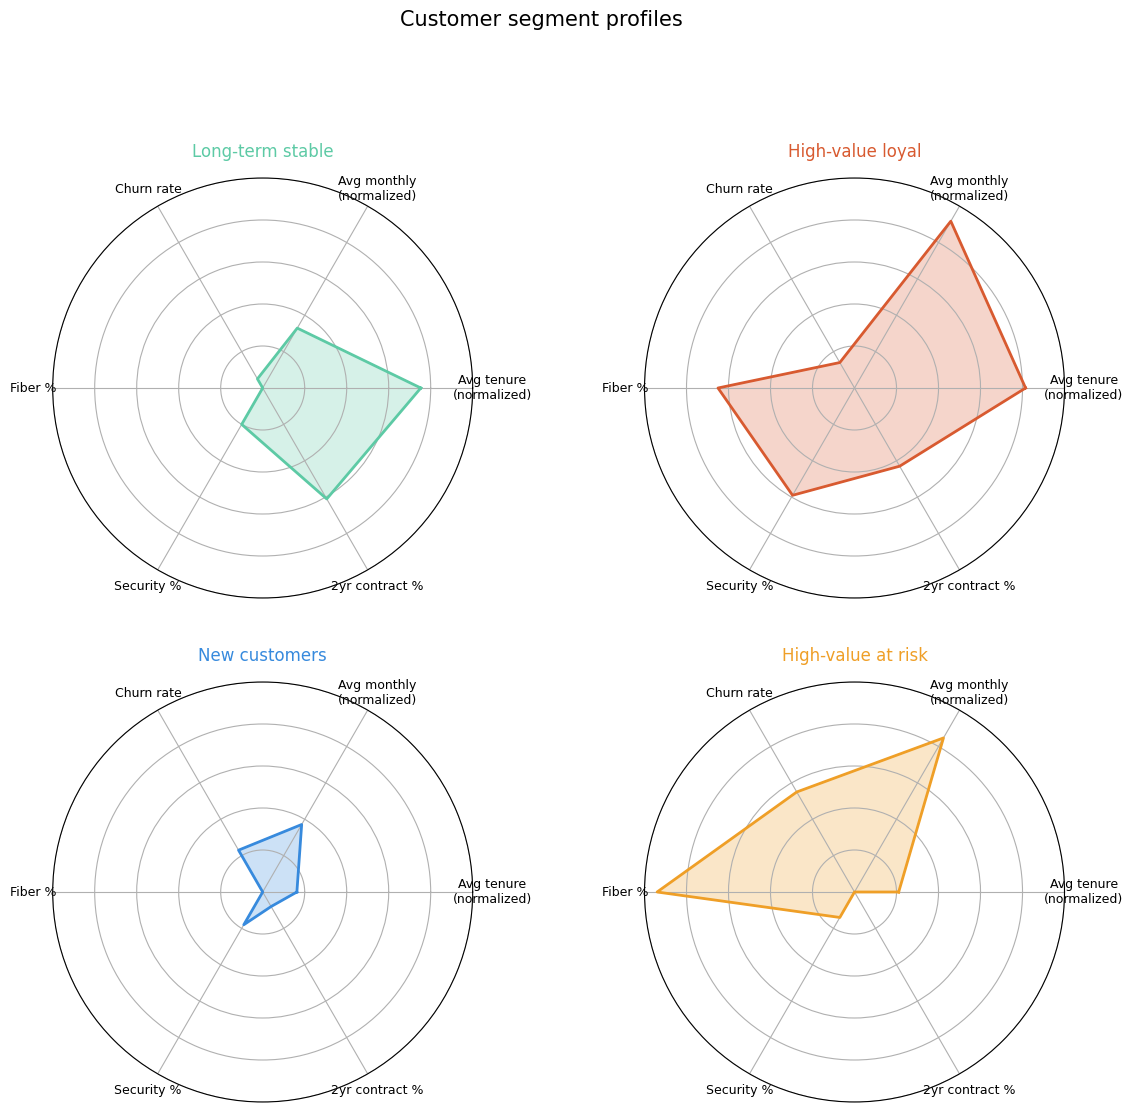

In [ ]:
#Radar chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Avg tenure\n(normalized)', 'Avg monthly\n(normalized)',
              'Churn rate', 'Fiber %', 'Security %', '2yr contract %']

# Normalize each metric to 0-1 scale for radar
def normalize(val, min_val, max_val):
    return (val - min_val) / (max_val - min_val)

radar_data = {
    'Long-term stable':   [normalize(54.21, 0, 72), normalize(32.93, 0, 100),
                          0.05, 0.00, 0.20, 0.61],
    'High-value loyal': [normalize(58.65, 0, 72), normalize(91.72, 0, 100),
                          0.14, 0.65, 0.59, 0.43],
    'New customers':      [normalize(11.72, 0, 72), normalize(37.11, 0, 100),
                          0.23, 0.00, 0.18, 0.08],
    'High-value at risk':  [normalize(15.14, 0, 72), normalize(84.71, 0, 100),
                          0.55, 0.94, 0.14, 0.00],
}

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (label, values) in enumerate(radar_data.items()):
    values += values[:1]

    ax = axes[idx]
    ax.plot(angles, values, color=cluster_colors[label], linewidth=2)
    ax.fill(angles, values, color=cluster_colors[label], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(label, size=12, pad=15, color=cluster_colors[label])
    ax.set_yticklabels([])

plt.suptitle('Customer segment profiles', fontsize=15, y=1.02)

plt.show()

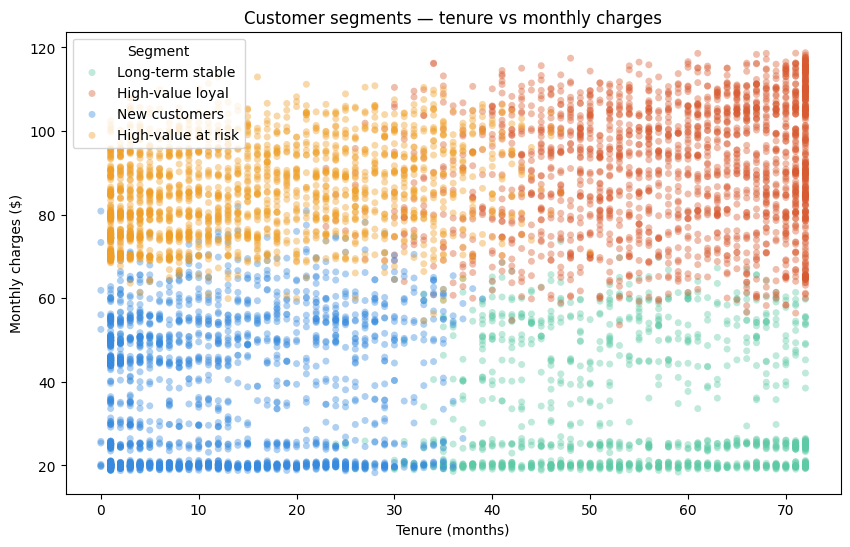

In [ ]:
#tenure vs monthly charges scatter plot
plt.figure(figsize=(10, 6))
for cluster_id, label in cluster_names.items():
    mask = df_unscaled['Cluster'] == cluster_id
    plt.scatter(df_unscaled[mask]['tenure'],
                df_unscaled[mask]['MonthlyCharges'],
                c=cluster_colors[label], label=label,
                alpha=0.4, s=25, edgecolors='none')

plt.title('Customer segments — tenure vs monthly charges')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly charges ($)')
plt.legend(title='Segment')

plt.show()

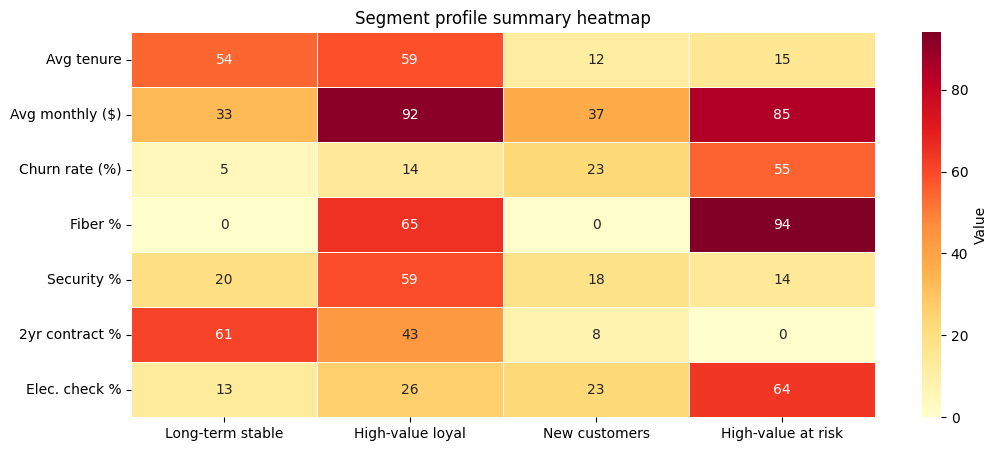

In [ ]:
#heatmap of all segment categories
summary = pd.DataFrame({
    'Avg tenure':      [54.21, 58.65, 11.72, 15.14],
    'Avg monthly ($)': [32.93, 91.72, 37.11, 84.71],
    'Churn rate (%)':  [5,     14,    23,    55],
    'Fiber %':         [0,     65,    0,     94],
    'Security %':      [20,    59,    18,    14],
    '2yr contract %':  [61,    43,    8,     0],
    'Elec. check %':   [13,    26,    23,    64],
}, index=cluster_names.values())

plt.figure(figsize=(12, 5))
sns.heatmap(summary.T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Value'})
plt.title('Segment profile summary heatmap')

plt.show()

In [22]:
#Evaluating churn prediction models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                            roc_curve, ConfusionMatrixDisplay)

In [23]:
#Training all 3 models
X = df.drop(columns=['Churn', 'Cluster', 'Cluster_Label'])
y = df['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state = 42, stratify = y
)

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

loreg = LogisticRegression(max_iter=1000, random_state=42)
rfc = RandomForestClassifier(n_estimators=1000, random_state=42)
xgb = XGBClassifier(n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,   # handles class imbalance natively
    random_state=42,
    eval_metric='logloss',
    verbosity=0)

loreg.fit(X_train_res, y_train_res)
rfc.fit(X_train_res, y_train_res)
xgb.fit(X_train_res, y_train_res)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
models = { 'Logisticregression':loreg,
            'Random Forest': rfc,
            'XGBoost': xgb
}
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc':    roc_auc_score(y_test, y_prob)
    }
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred,
                                target_names=['No churn', 'Churned']))
    print(f"  ROC-AUC: {results[name]['auc']:.4f}")




  Logisticregression
              precision    recall  f1-score   support

    No churn       0.89      0.77      0.82      1035
     Churned       0.53      0.73      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

  ROC-AUC: 0.8305

  Random Forest
              precision    recall  f1-score   support

    No churn       0.85      0.82      0.83      1035
     Churned       0.55      0.61      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.77      1409

  ROC-AUC: 0.8164

  XGBoost
              precision    recall  f1-score   support

    No churn       0.93      0.59      0.72      1035
     Churned       0.44      0.89      0.59       374

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.6

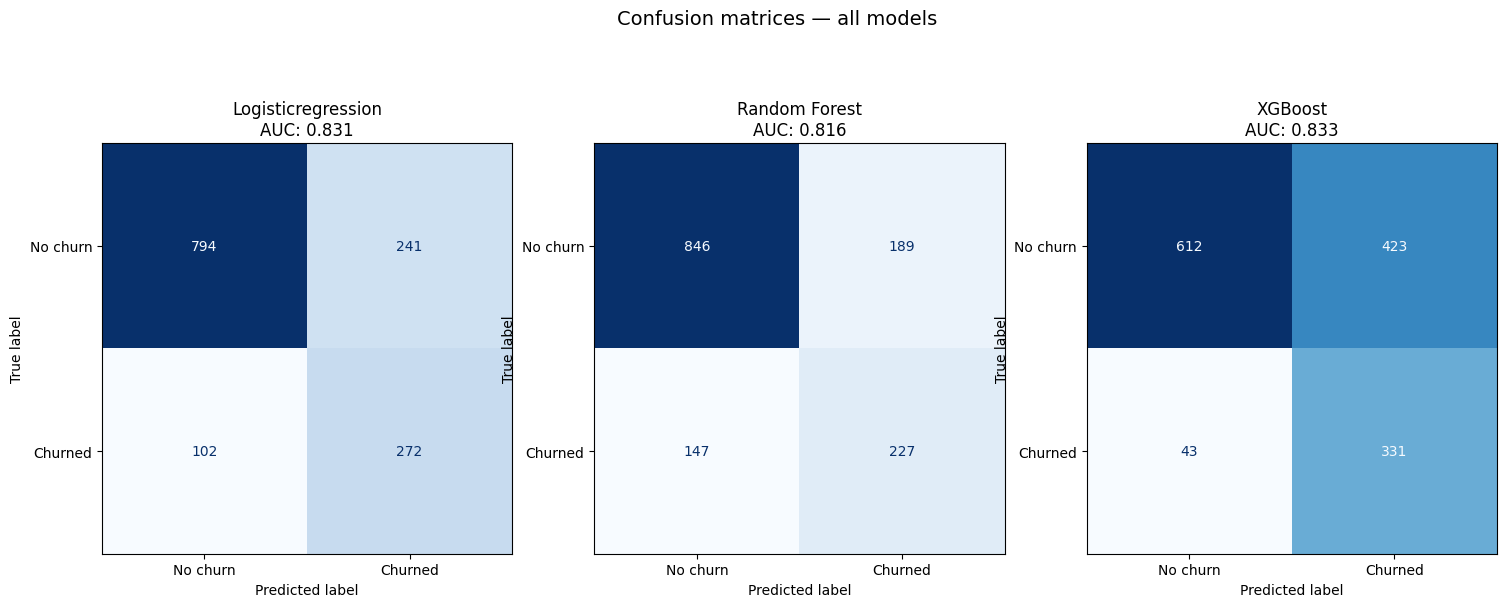

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC: {res["auc"]:.3f}')

plt.suptitle('Confusion matrices — all models', fontsize=14)

plt.show()

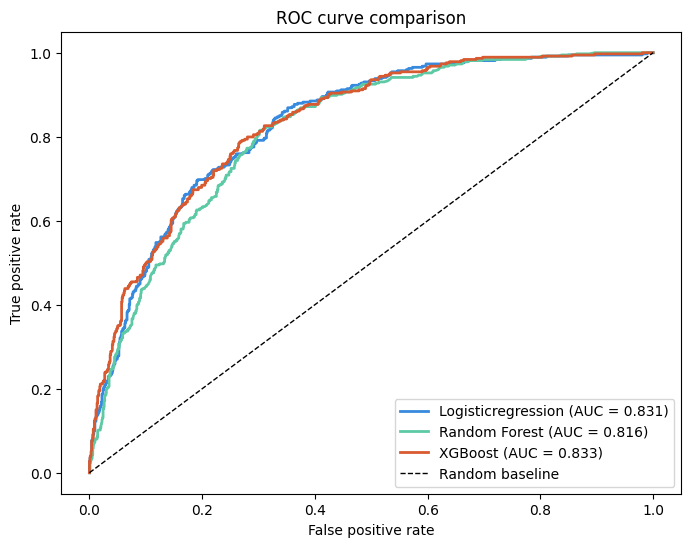

In [26]:
plt.figure(figsize=(8, 6))
colors = ['#378ADD', '#5DCAA5', '#D85A30']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {res["auc"]:.3f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random baseline')
plt.title('ROC curve comparison')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()

plt.show()

In [ ]:
#both logistic regression and XGBoost models are better but XGBoost has higher AUC

In [27]:
# Use your best model (likely XGBoost)
df_unscaled['Churn_Probability'] = xgb.predict_proba(X)[:, 1]

# Now you can see churn risk per segment
churn_prob_by_segment = df_unscaled.groupby('Cluster_Label')['Churn_Probability'].mean()
print(churn_prob_by_segment.sort_values(ascending=False))

Cluster_Label
High-value at risk    0.854369
New customers         0.515856
High-value loyal      0.361338
Long-term stable      0.160680
Name: Churn_Probability, dtype: float32


In [28]:
import shap
shap.initjs()

In [29]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print(shap_values.shape)

(1409, 22)


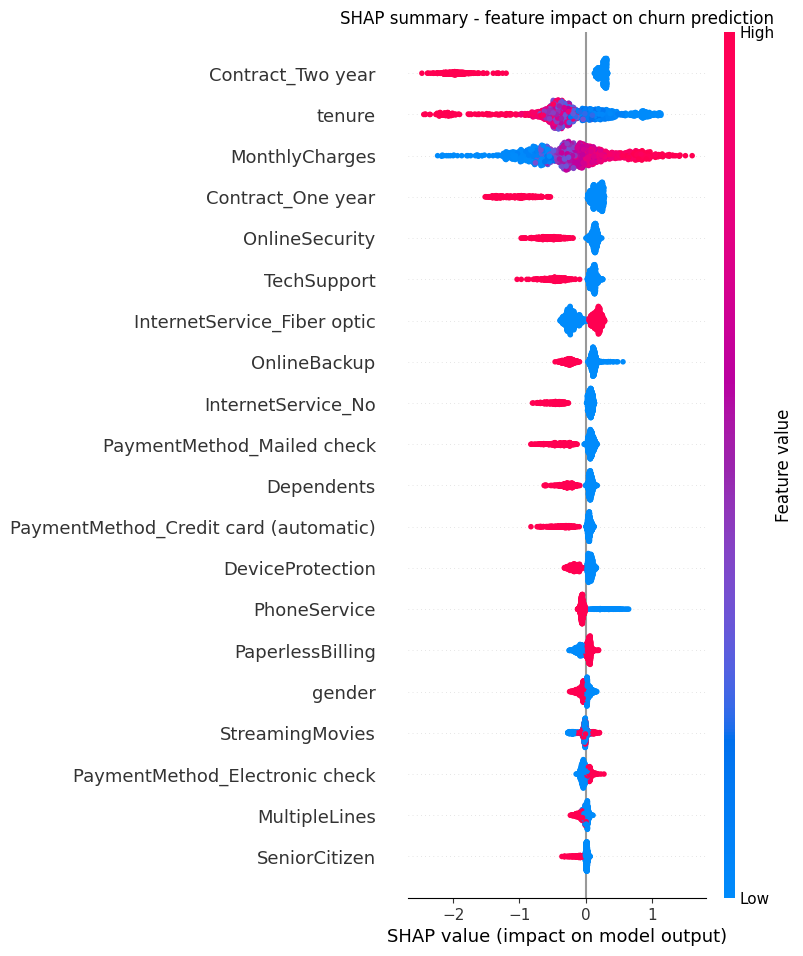

In [30]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist(),
                  show=False)
plt.title('SHAP summary - feature impact on churn prediction')
plt.show()
#red dots- high feature value
#blue dots - low feature value
# minus value pushes towards no churn and plus pushes towards churn

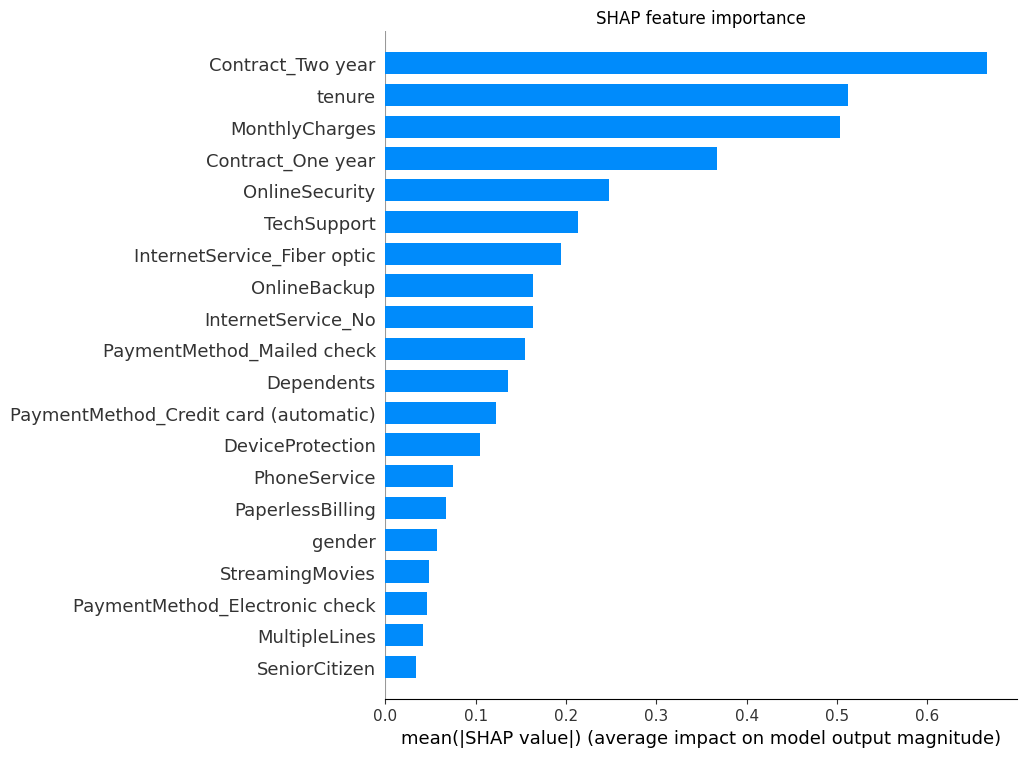

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.gcf().set_size_inches(10,8)
plt.subplots_adjust(left=0.35, bottom=0.15)
plt.title('SHAP feature importance')
plt.show()

Top 3 features: ['Contract_Two year', 'tenure', 'MonthlyCharges']


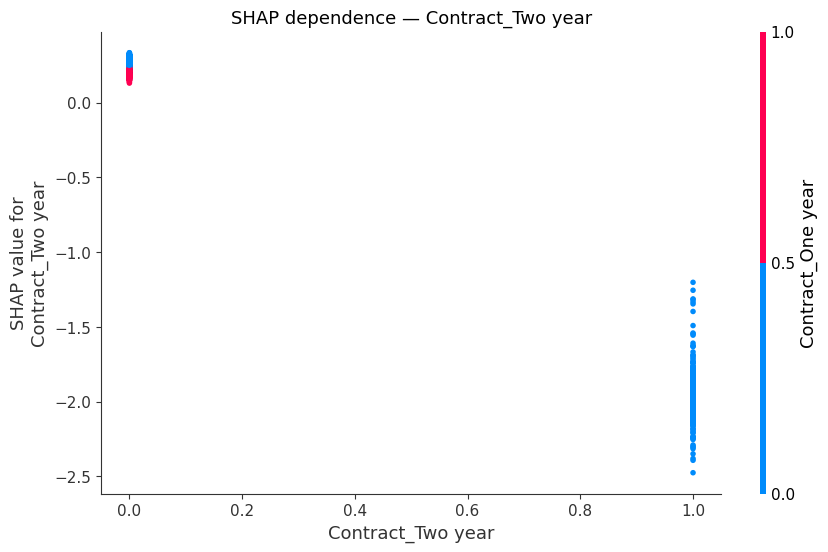

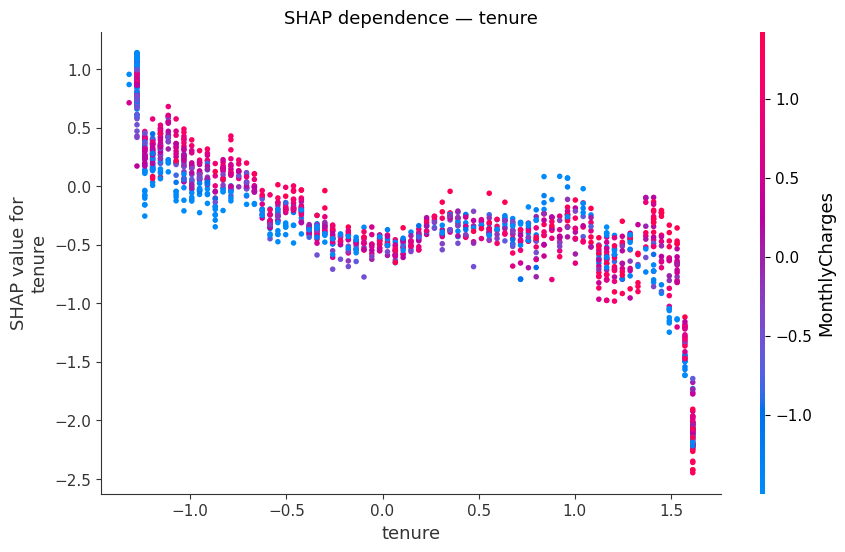

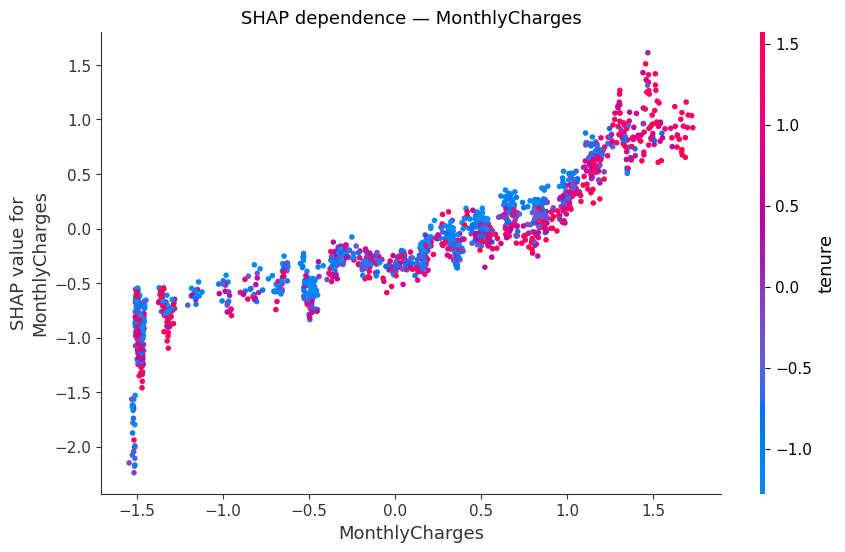

In [31]:
feature_importance=pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

top3 = feature_importance.head(3).index.tolist()
print('Top 3 features:', top3)

for feature in top3:
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.dependence_plot(feature, shap_values, X_test,
                         feature_names=X_test.columns.tolist(),
                         ax=ax,
                         show=False)
    ax.set_title(f'SHAP dependence — {feature}', fontsize=13)

    plt.show()
    plt.close()  # close figure after each plot to prevent overlap

In [35]:
#waterfall plot
churners = np.where((y_test.values == 1) &
                        (xgb.predict(X_test) == 1))[0]

print(f"Total number of churners: {churners}")
churner_idx = churners[3]
print(f"Actual churn: {y_test.values[churner_idx]}")
print(f"Predicted churn probability: {xgb.predict_proba(X_test)[churner_idx, 1]:.2f}")



Total number of churners: [   9   13   20   26   27   29   34   36   38   39   45   49   51   55
   64   65   67   69   72   77   82   83   87   88   90   93   94   98
  100  101  103  104  114  116  121  124  126  128  130  131  139  147
  154  157  158  159  167  171  173  180  182  183  187  192  210  218
  228  231  234  235  236  240  241  244  245  246  254  264  266  276
  278  285  288  301  304  318  319  322  336  341  343  344  347  349
  359  360  365  370  374  384  386  387  389  399  408  410  411  412
  413  417  419  423  435  441  444  456  459  470  478  479  483  488
  497  508  510  511  514  523  525  533  538  539  540  542  544  556
  557  562  566  567  568  569  572  573  575  586  589  593  594  598
  601  603  607  613  618  619  621  622  625  627  628  630  632  647
  648  650  653  654  674  678  679  685  693  695  707  710  713  714
  717  728  729  731  735  740  743  744  745  749  758  762  771  774
  776  783  788  794  797  799  813  816  818  826 

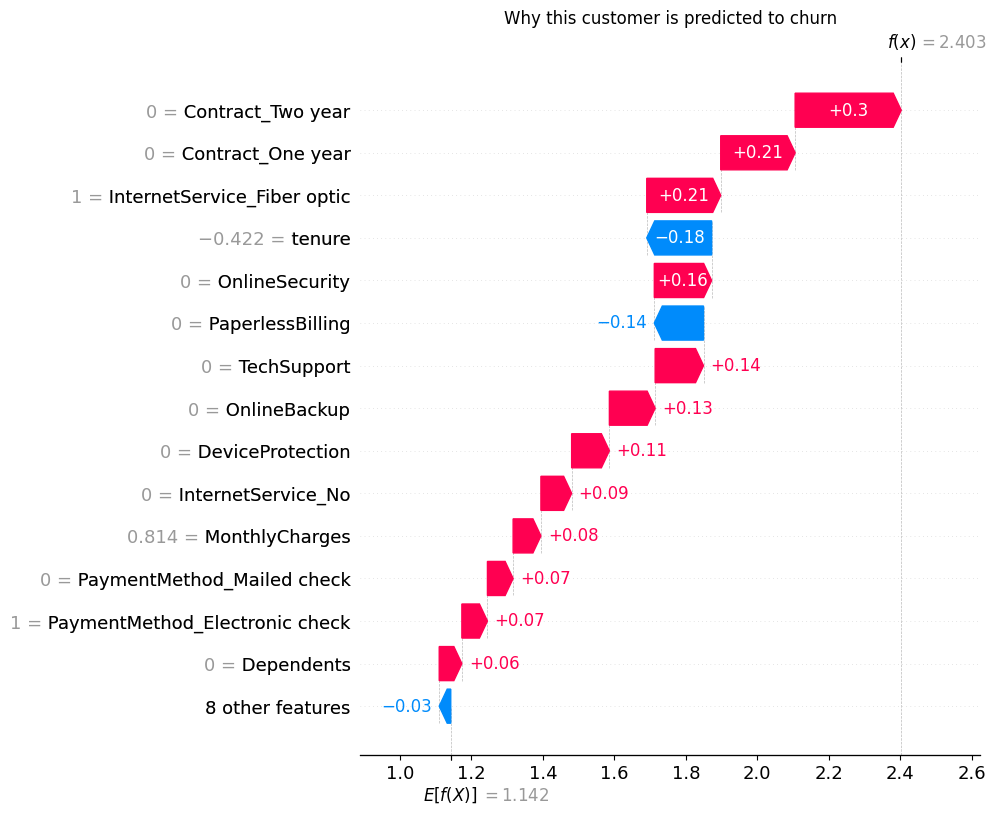

In [36]:
# Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[churner_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[churner_idx].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False, max_display=15)
plt.title('Why this customer is predicted to churn')

plt.show()

                    avg_risk  high_risk_count
Cluster_Label                                
High-value at risk     0.854             1858
New customers          0.516             1143
High-value loyal       0.361              658
Long-term stable       0.161              113


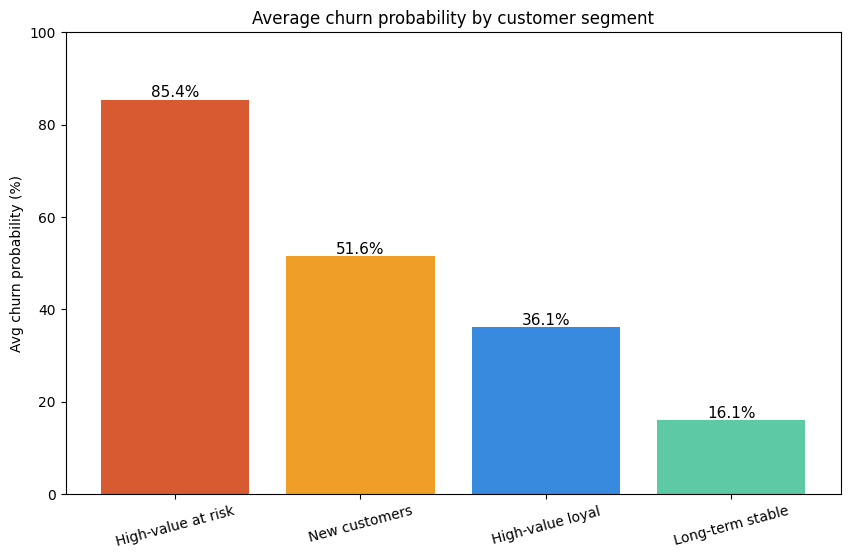

In [ ]:
# Get churn probabilities for entire dataset
X_full = df.drop(columns=['Churn', 'Cluster', 'Cluster_Label'])
df_unscaled['Churn_Probability'] = xgb.predict_proba(X_full)[:, 1]

# Average churn probability per segment
risk_by_segment = df_unscaled.groupby('Cluster_Label')['Churn_Probability'].agg(
    avg_risk='mean',
    high_risk_count=lambda x: (x >= 0.5).sum()
).round(3).sort_values('avg_risk', ascending=False)

print(risk_by_segment)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(risk_by_segment.index,
               risk_by_segment['avg_risk'] * 100,
               color=['#D85A30', '#EF9F27', '#378ADD', '#5DCAA5'],
               edgecolor='none')
for bar, val in zip(bars, risk_by_segment['avg_risk'] * 100):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11)
plt.title('Average churn probability by customer segment')
plt.ylabel('Avg churn probability (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)

plt.show()

In [ ]:
## Key SHAP findings
'''
1. tenure — most protective feature. Long-tenure customers
   have strongly negative SHAP values = very unlikely to churn.

2. Contract_Two year — second most protective. Being on a
   2-year contract dramatically reduces churn probability.

3. InternetService_Fiber optic — top risk driver. Fiber optic
   customers have high positive SHAP values = high churn risk,
   suggesting service quality or pricing dissatisfaction.

4. PaymentMethod_Electronic check — second risk driver.
   Electronic check users are significantly more likely to churn.

5. MonthlyCharges — high charges push toward churn, especially
   when combined with month-to-month contract.
   '''

In [37]:
# Get churn probabilities for entire dataset
X_full = df.drop(columns=['Churn', 'Cluster', 'Cluster_Label'])
df_unscaled['Churn_Probability'] = xgb.predict_proba(X_full)[:, 1]

# Summary per segment
segment_risk = df_unscaled.groupby('Cluster_Label').agg(
    num_customers     = ('Churn_Probability', 'count'),
    avg_churn_prob    = ('Churn_Probability', 'mean'),
    high_risk_count   = ('Churn_Probability', lambda x: (x >= 0.5).sum()),
    actual_churn_rate = ('Churn', 'mean')
).round(3).sort_values('avg_churn_prob', ascending=False)

segment_risk['high_risk_pct'] = (
    segment_risk['high_risk_count'] / segment_risk['num_customers'] * 100
).round(1)

print(segment_risk)

                    num_customers  avg_churn_prob  high_risk_count  \
Cluster_Label                                                        
High-value at risk           1943           0.854             1858   
New customers                2038           0.516             1143   
High-value loyal             1957           0.361              658   
Long-term stable             1105           0.161              113   

                    actual_churn_rate  high_risk_pct  
Cluster_Label                                         
High-value at risk              0.555           95.6  
New customers                   0.232           56.1  
High-value loyal                0.136           33.6  
Long-term stable                0.046           10.2  


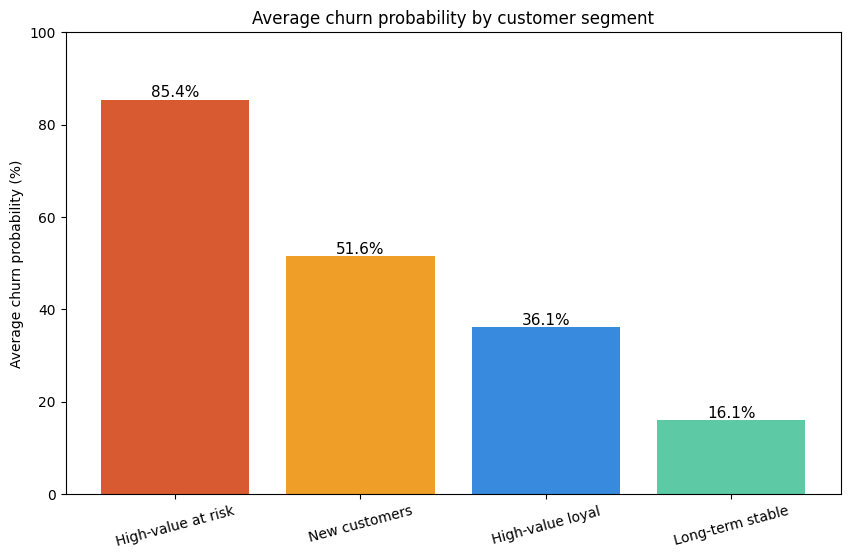

In [ ]:
segment_risk_sorted = segment_risk.sort_values('avg_churn_prob', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_risk_sorted.index,
               segment_risk_sorted['avg_churn_prob'] * 100,
               color=['#D85A30', '#EF9F27', '#378ADD', '#5DCAA5'],
               edgecolor='none')

for bar, val in zip(bars, segment_risk_sorted['avg_churn_prob'] * 100):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11)

plt.title('Average churn probability by customer segment')
plt.ylabel('Average churn probability (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.show()

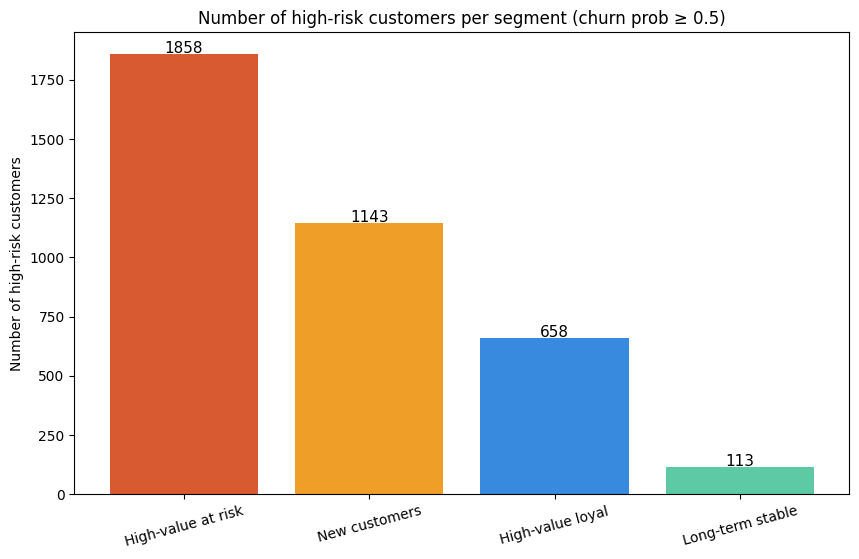

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(segment_risk_sorted.index,
               segment_risk_sorted['high_risk_count'],
               color=['#D85A30', '#EF9F27', '#378ADD', '#5DCAA5'],
               edgecolor='none')

for bar, val in zip(bars, segment_risk_sorted['high_risk_count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(int(val)), ha='center', fontsize=11)

plt.title('Number of high-risk customers per segment (churn prob ≥ 0.5)')
plt.ylabel('Number of high-risk customers')
plt.xticks(rotation=15)

plt.show()

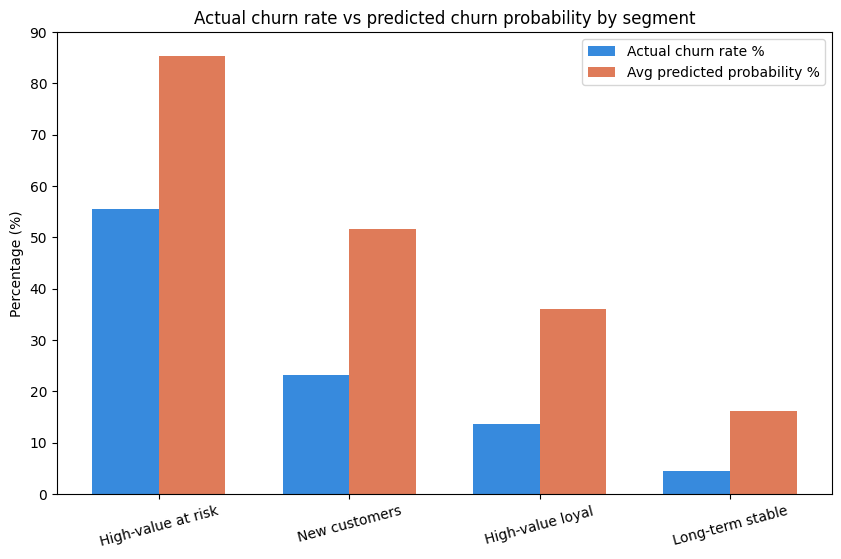

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(segment_risk_sorted))
width = 0.35

# Actual churn rate bars
bars1 = ax1.bar(x - width/2,
                segment_risk_sorted['actual_churn_rate'] * 100,
                width, label='Actual churn rate %',
                color='#378ADD', edgecolor='none')

# Predicted probability bars
bars2 = ax1.bar(x + width/2,
                segment_risk_sorted['avg_churn_prob'] * 100,
                width, label='Avg predicted probability %',
                color='#D85A30', edgecolor='none', alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(segment_risk_sorted.index, rotation=15)
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Actual churn rate vs predicted churn probability by segment')
ax1.legend()
ax1.set_ylim(0, 90)

plt.show()

X threshold (avg churn prob): 51.1%
Y threshold (avg monthly charges): 64.8


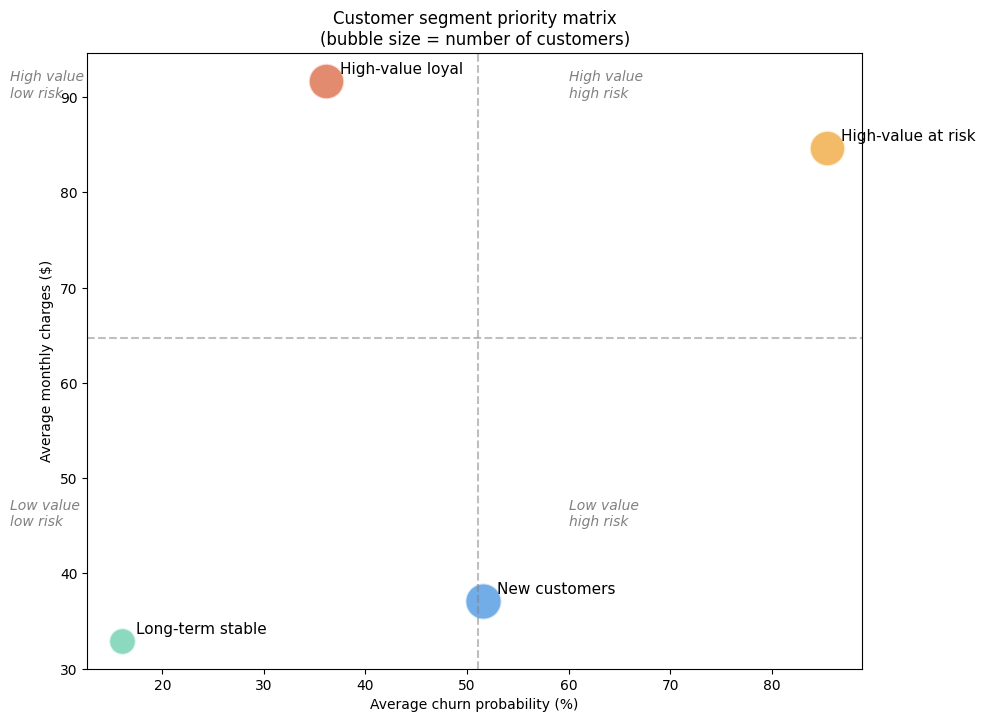

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot each segment as a bubble
# x = avg churn probability, y = avg monthly charges, size = num customers
for idx, row in df_unscaled.groupby('Cluster_Label').agg(
    avg_prob    = ('Churn_Probability', 'mean'),
    avg_monthly = ('MonthlyCharges', 'mean'),
    count       = ('Churn_Probability', 'count')
).iterrows():
    ax.scatter(row['avg_prob'] * 100, row['avg_monthly'],
               s=row['count'] / 3,
               color=cluster_colors[idx],
               alpha=0.7, edgecolors='white', linewidth=1.5)
    ax.annotate(idx,
                (row['avg_prob'] * 100, row['avg_monthly']),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11)


x_threshold = df_unscaled['Churn_Probability'].mean() * 100  # mean churn prob
y_threshold = df_unscaled['MonthlyCharges'].mean()           # mean monthly charges

print(f"X threshold (avg churn prob): {x_threshold:.1f}%")
print(f"Y threshold (avg monthly charges): {y_threshold:.1f}")

ax.axvline(x=x_threshold, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=y_threshold, color='gray', linestyle='--', alpha=0.5)


# Quadrant labels
ax.text(5,  90, 'High value\nlow risk',    fontsize=10, color='gray', style='italic')
ax.text(60, 90, 'High value\nhigh risk',  fontsize=10, color='gray', style='italic')
ax.text(5,  45, 'Low value\nlow risk',     fontsize=10, color='gray', style='italic')
ax.text(60, 45, 'Low value\nhigh risk',    fontsize=10, color='gray', style='italic')

ax.set_xlabel('Average churn probability (%)')
ax.set_ylabel('Average monthly charges ($)')
ax.set_title('Customer segment priority matrix\n(bubble size = number of customers)')
plt.show()

In [38]:
summary = pd.DataFrame({
    'Segment':          ['High-value at-risk', 'New customers',
                         'High-value loyal', 'Long-term stable'],
    'Size':             [1943, 2038, 1957, 1105],
    'Churn rate':       ['55%', '23%', '14%', '5%'],
    'Avg monthly ($)':  [84.71, 37.11, 91.72, 32.93],
    'Priority':         ['URGENT', 'NURTURE', 'MAINTAIN', 'REWARD'],
    'Key action':       ['Contract upgrade offer',
                         '90-day onboarding program',
                         'Loyalty reward program',
                         'Referral + upsell program'],
    'Est. monthly gain':['$32,592', '$6,053', '$10,737', '$2,210']
})

print(summary.to_string(index=False))

           Segment  Size Churn rate  Avg monthly ($) Priority                Key action Est. monthly gain
High-value at-risk  1943        55%            84.71   URGENT    Contract upgrade offer           $32,592
     New customers  2038        23%            37.11  NURTURE 90-day onboarding program            $6,053
  High-value loyal  1957        14%            91.72 MAINTAIN    Loyalty reward program           $10,737
  Long-term stable  1105         5%            32.93   REWARD Referral + upsell program            $2,210


In [41]:
from google.colab import files
import pickle
with open('xgb_model.pkl','wb') as f:
  pickle.dump(xgb, f)

with open('scaler.pkl','wb') as f:
  pickle.dump(scaler, f)

files.download('xgb_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>